▶ Running Improved Complex MP-PCA...
   Applying phase correction...
   Applying spatial variance normalization...
   Completed in 167.8s
   Average signal components: 2.1
   Min/Max components: 1/4
▶ Running Improved Complex MP-PCA...
   Applying phase correction...
   Applying spatial variance normalization...
   Completed in 171.2s
   Average signal components: 2.1
   Min/Max components: 1/4
▶ Echo-wise Bias-Corrected SNR Summary:
      Echo  SNR_Noisy_BC  SNR_Complex_BC  ΔSNR_Complex
0        0        3.9900        4.428000      0.439000
1        1        3.6110        4.098000      0.487000
2        2        3.2500        3.759000      0.509000
3        3        2.9270        3.457000      0.530000
4        4        2.6320        3.150000      0.518000
5        5        2.3550        2.817000      0.462000
6  Average        3.1275        3.618167      0.490833
▶ Calculating slice-wise metrics…


/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


▶ Slice-wise Bias-Corrected SNR (예시 일부):
   Slice  Echo  SNR_Noisy_BC  SNR_Complex_BC
0      7     0         1.791           3.067
1      8     0         0.000           0.000
2      9     0         0.000           0.000
3     10     0         0.000           0.000
4     11     0         0.000           0.000


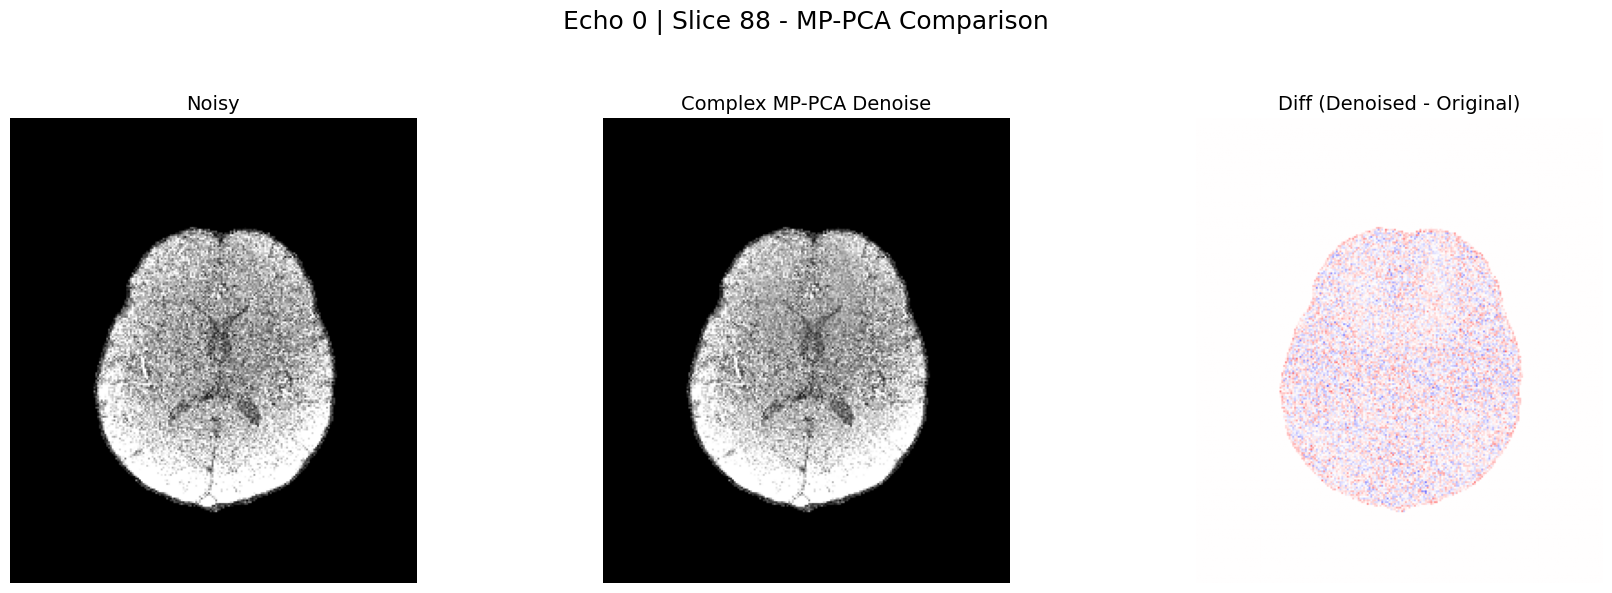

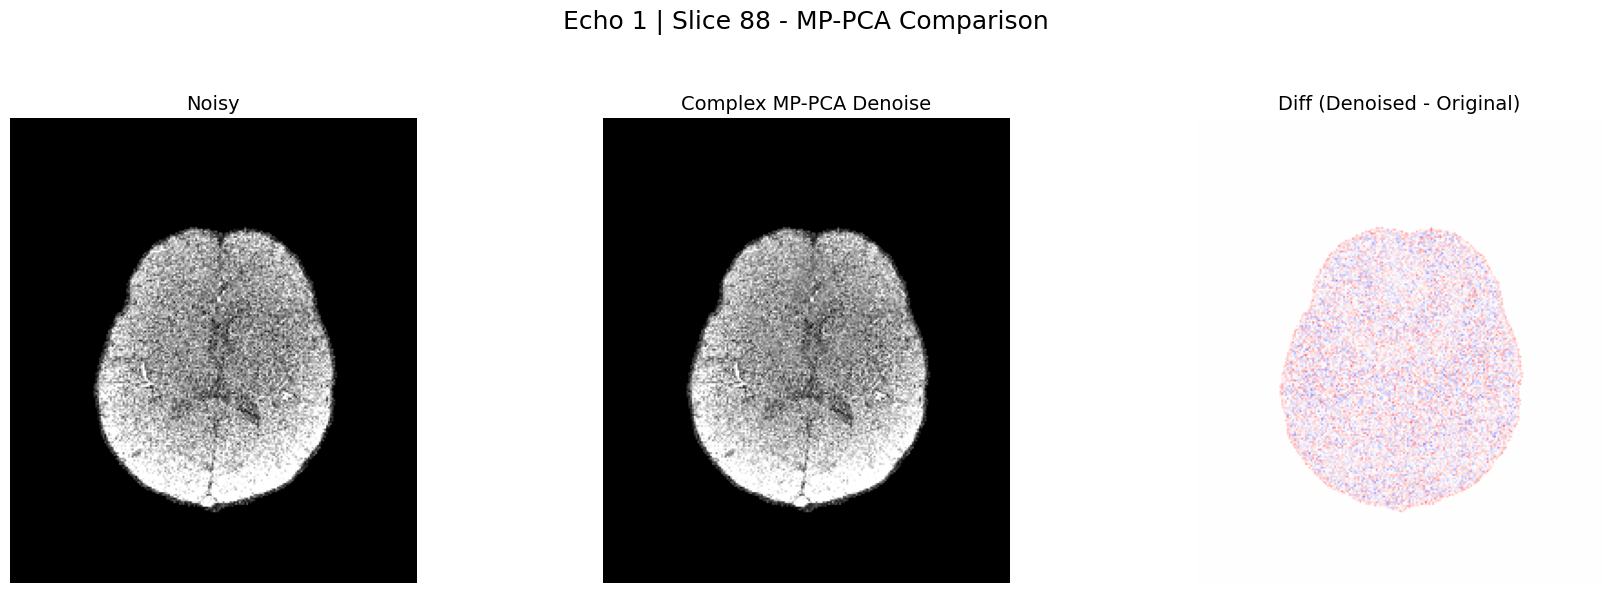

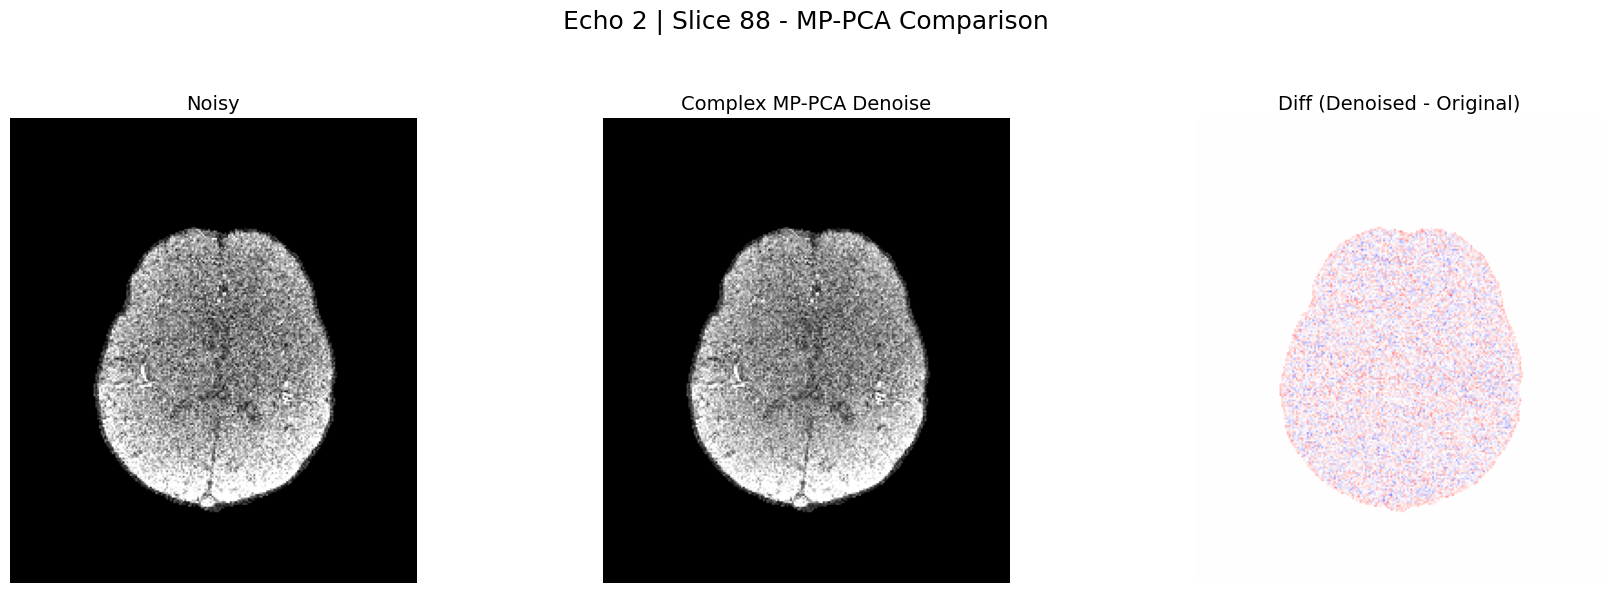

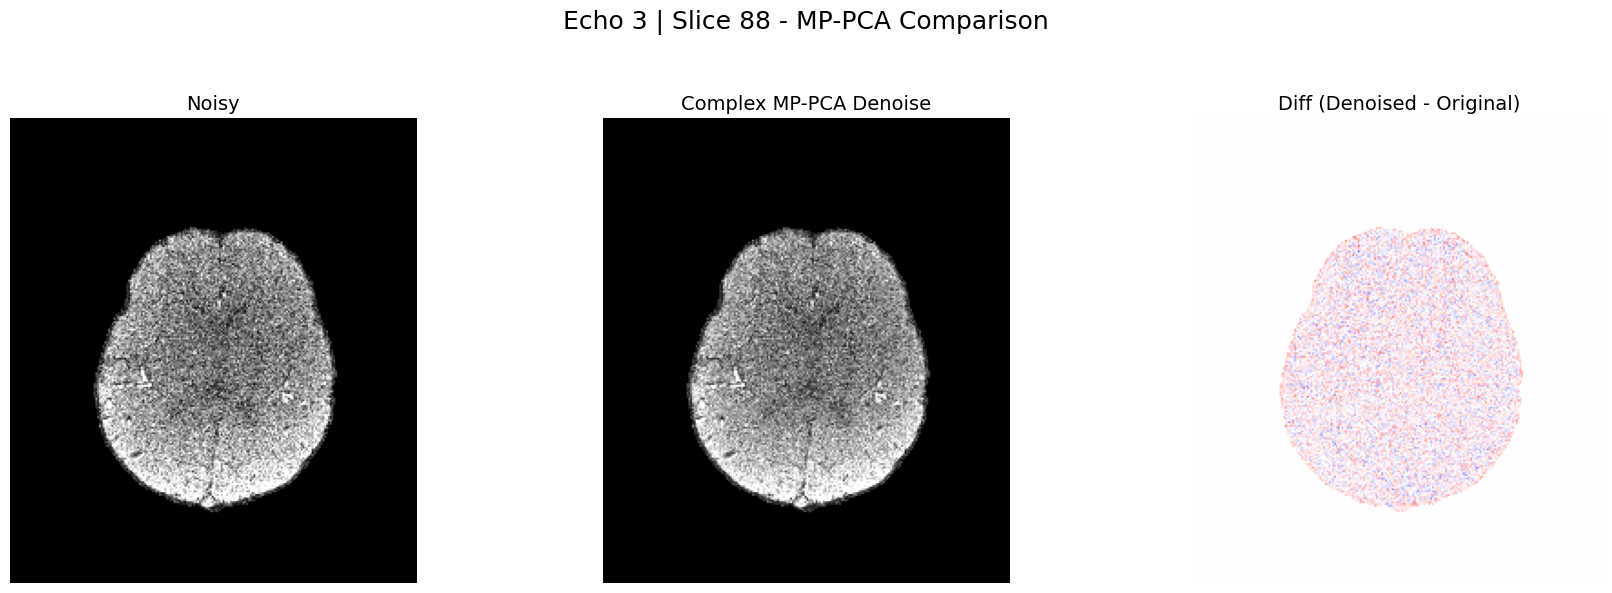

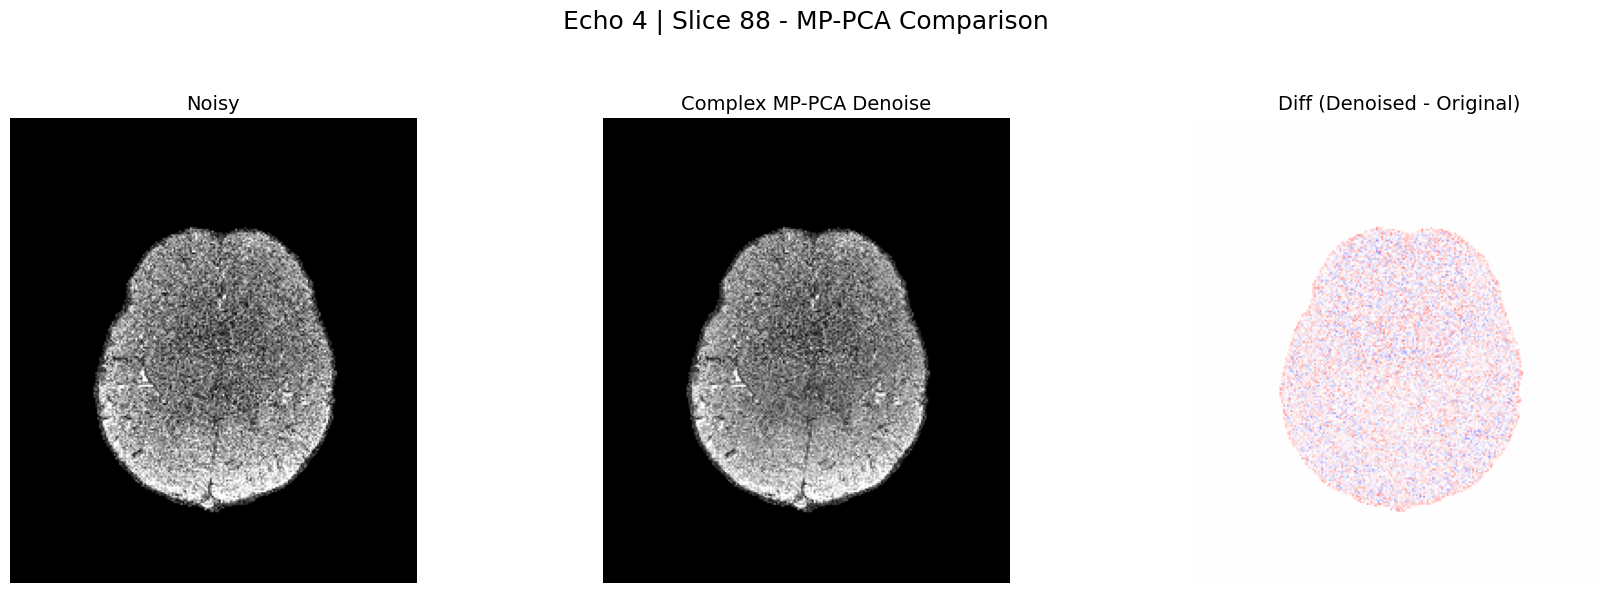

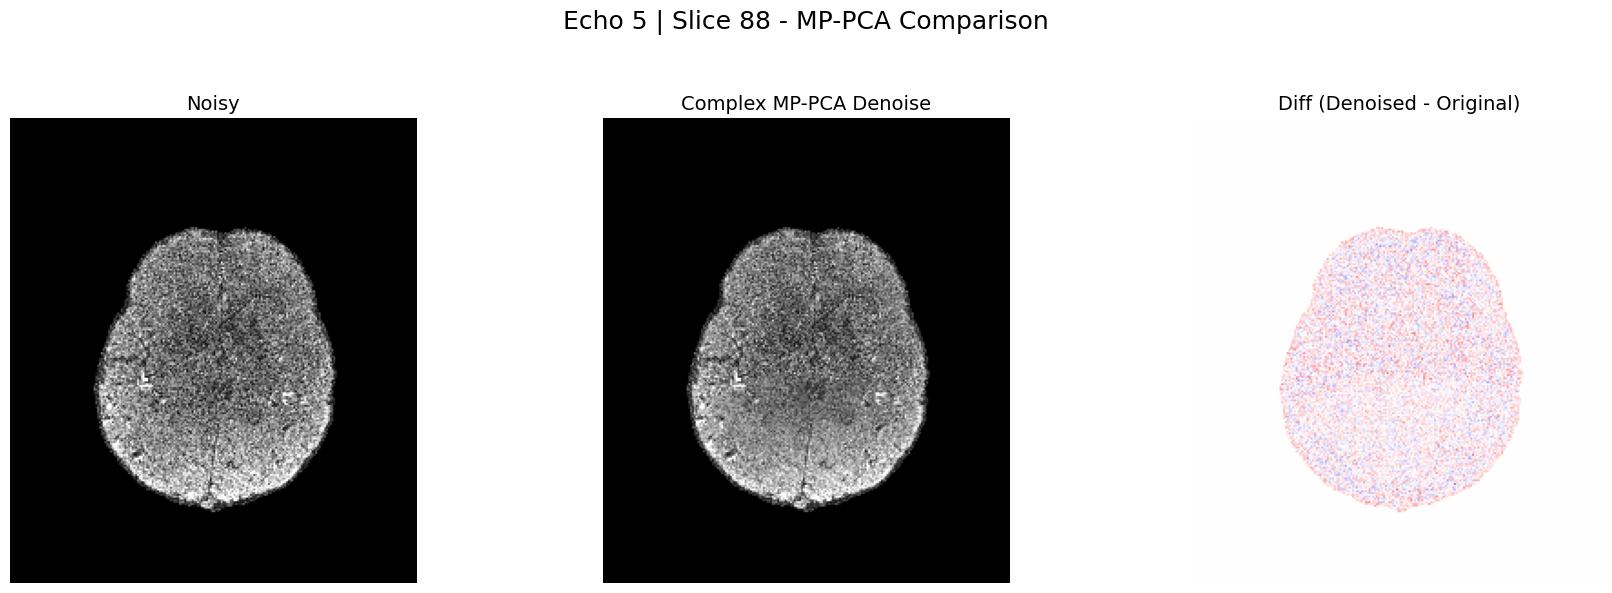

▶ Final Echo-wise Bias-Corrected SNR Summary:
      Echo  SNR_Noisy_BC  SNR_Complex_BC  ΔSNR_Complex
0        0        3.9900        4.428000      0.439000
1        1        3.6110        4.098000      0.487000
2        2        3.2500        3.759000      0.509000
3        3        2.9270        3.457000      0.530000
4        4        2.6320        3.150000      0.518000
5        5        2.3550        2.817000      0.462000
6  Average        3.1275        3.618167      0.490833

▶ Example Slice-wise Bias-Corrected SNR (Echo=0 일부):
   Slice  Echo  SNR_Noisy_BC  SNR_Complex_BC
0      7     0         1.791           3.067
1      8     0         0.000           0.000
2      9     0         0.000           0.000
3     10     0         0.000           0.000
4     11     0         0.000           0.000
5     12     0         0.000           0.000
6     13     0         0.000           0.000
7     14     0         0.000           0.136
8     15     0         0.000           0.412
9     16  

In [ ]:
import numpy as np
import scipy.io as sio
import time
import matplotlib.pyplot as plt
import pandas as pd
from  kpcac import improved_complex_mppca
from skimage.metrics import structural_similarity as ssim

# ----------------------- Parameters -----------------------
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
EPSILON         = 1e-12     # SNR 계산 시 0으로 나누기 방지용 작은 값
SLICE_IDX       = None      # None이면 중앙 슬라이스 (Z//2) 사용
do_return_sigma = True      # True면 sigma_map도 반환

# ----------------------- Load data -----------------------
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
meas_gre   = orig_mat['meas_gre']                  # shape (X, Y, Z, Ne), dtype=complex
mask_brain = orig_mat['mask_brain'].astype(bool)   # shape (X, Y, Z), bool 타입

        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
noisy_real = noise_mat['noisy_real'].astype(np.float32)  # shape (X, Y, Z, Ne), float32
noisy_imag = noise_mat['noisy_imag'].astype(np.float32)  # shape (X, Y, Z, Ne), float32

# 볼륨 크기 및 슬라이스 인덱스 결정
X, Y, Z, Ne = meas_gre.shape
if SLICE_IDX is None:
    SLICE_IDX = Z // 2

# ----------------------- Prepare magnitudes -----------------------
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# ----------------------- Complex MP-PCA -----------------------
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
noisy_complex = noisy_real + 1j * noisy_imag
# 고급 설정
if do_return_sigma:
    denoised, sigma_map = improved_complex_mppca(
    noisy_complex,
    mask=mask_brain,
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        threshold_method='tpca',       # TPCA 임계값 방법
    phase_correction=True,         # 위상 보정 적용
    variance_normalization=True,   # 공간 분산 정규화
        patch_radius=PATCH_RADIUS,       # 패치 반지름 사용 (예: 3)
        return_sigma=True            # 노이즈 맵 반환 여부
    )
else:
    denoised = improved_complex_mppca(
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

denoised, sigma_map = improved_complex_mppca(
    noisy_complex,
    mask=mask_brain,
    return_sigma=True
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
# ----------------------- Bias-corrected SNR functions -----------------------
def snr_diff_rician(ref, test, roi):
    """
    Rician 바이어스 보정 SNR 계산 함수
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
    - test: 비교할 진폭 볼륨 (예: noisy 또는 denoised), 같은 shape
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
    """
    s = []
    for c in range(ref.shape[3]):
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        # Rician 바이어스 보정:
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# ----------------------- Calculate echo-wise bias-corrected SNR -----------------------
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# Echo별 성능 요약 DataFrame 생성
df_echo_bc = pd.DataFrame({
    "Echo":            np.arange(Ne),
    "SNR_Noisy_BC":    snr_noisy_bc,
    "SNR_Complex_BC":  snr_cmplx_bc,
    "ΔSNR_Complex":    snr_cmplx_bc - snr_noisy_bc
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# 평균 행 추가
avg_dict = {
    "Echo": "Average",
    "SNR_Noisy_BC": df_echo_bc["SNR_Noisy_BC"].mean(),
    "SNR_Complex_BC": df_echo_bc["SNR_Complex_BC"].mean(),
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
}
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# ----------------------- Slice-wise bias-corrected SNR 계산 함수 -----------------------
def snr_slice_df_bc(ref, test, roi, label):
    """
    슬라이스 단위로 Rician 바이어스 보정 SNR 계산 후 DataFrame 생성
    - ref, test: (X, Y, Z, Ne) 볼륨
    - roi: (X, Y, Z) 마스크
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
    """
    rows = []
    Xdim, Ydim, Zdim, C = ref.shape
    for z in range(Zdim):
        mask2d = roi[:, :, z]
        if not mask2d.any():
            continue
        for c in range(C):
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# 두 DataFrame 병합 및 정렬
df_slice_all = (df_snr_noisy
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# ----------------------- Visualization Settings -----------------------
# 시각화 시 밝기 범위(vmin, vmax) 설정
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
max_diff = max(
    np.abs(mag_noisy - mag_orig).max(),
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# ----------------------- Enhanced Visualization (3 panels) -----------------------
for e in range(Ne):
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

    # 1) Noisy
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

    # 2) Complex MP-PCA Denoise
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
    diff_cmplx = mag_den_cmplx[:, :, SLICE_IDX, e] - mag_orig[:, :, SLICE_IDX, e]
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )

# ----------------------- Performance Summary 출력 -----------------------
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
        noisy_complex,
        mask=mask_brain,
        pca_method='svd',
        threshold_method='tpca',
        phase_correction=True,
        variance_normalization=True,
        patch_radius=PATCH_RADIUS,
        return_sigma=False
    )
